In [1]:
from matplotlib import pyplot as plt
import numpy as np
import mne
import mne_icalabel

In [2]:
# Enable interactive plots
# %matplotlib ipympl

# Define the file path
file_path = "EEG Motor Movement:Imagery Dataset/sub-001/eeg/sub-001_task-motion_run-3_eeg.set"

# Load the .set file using mne
raw = mne.io.read_raw_eeglab(file_path, preload=True)

# Print the raw info to verify
# print(raw.info)
# raw.plot(duration=60, scalings={'eeg': 100e-6})


In [3]:
rawCopy = raw.copy()

# Plot the Power Spectral Density (PSD) of the raw data
# rawCopy.compute_psd().plot()
rawCopy.notch_filter(freqs=60)
rawCopy.filter(l_freq=1, h_freq=None)
# rawCopy.compute_psd().plot()

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 529 samples

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


<RawEEGLAB | sub-001_task-motion_run-3_eeg.set, 64 x 20000 (125.0 s), ~9.8 MB, data loaded>

In [4]:
rawCopy.info['bads'].extend(['Iz', 'Oz', 'O1', 'O2', 'Poz', 'Po3', 'Po4', 'Po7', 'Po8'])
rawCopy.set_eeg_reference('average')
# rawCopy.plot(duration=10, scalings={'eeg': 50e-6})

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
<Info | 10 non-empty values
 bads: 9 items (Iz, Oz, O1, O2, Poz, Po3, Po4, Po7, Po8)
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: True
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 1.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


In [8]:
print(len(rawCopy.info['chs'])-len(rawCopy.info['bads']))

55


In [114]:
ica = mne.preprocessing.ICA(n_components=54, random_state=0, method='infomax', fit_params=dict(extended=True))
ica.fit(rawCopy)
# ica.plot_components()
labels = mne_icalabel.label_components(rawCopy, ica, method='iclabel')
print(labels)
ica.exclude = [idx for idx, label in enumerate(labels['labels']) if label != 'brain']
# ica.plot_components()
# ica.plot_properties(rawCopy, picks=[idx for idx, label in enumerate(labels['labels']) if label == 'brain'])
# ica.plot_properties(raw, picks=ica.exclude)
rawCopyWithICA = ica.apply(rawCopy.copy())

Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 54 components
Computing Extended Infomax ICA
Fitting ICA took 2.7s.


/var/folders/b6/20mcgwl17j75xmyj_0cxrp800000gn/T/ipykernel_12354/336556374.py:4: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = mne_icalabel.label_components(rawCopy, ica, method='iclabel')


{'y_pred_proba': array([0.98814225, 0.70092446, 0.9533845 , 0.8165472 , 0.8600961 ,
       0.48526675, 0.64313805, 0.9366443 , 0.94115394, 0.30494782,
       0.4556825 , 0.91737205, 0.46327266, 0.83986896, 0.552745  ,
       0.71590436, 0.98718035, 0.68680423, 0.89498365, 0.5000113 ,
       0.5172674 , 0.8320392 , 0.7822993 , 0.62177837, 0.6918041 ,
       0.923904  , 0.7424133 , 0.62118995, 0.5039549 , 0.40158507,
       0.67408645, 0.8930768 , 0.88646525, 0.63264304, 0.5131001 ,
       0.7846596 , 0.9446698 , 0.9264074 , 0.58735394, 0.86516404,
       0.5711266 , 0.9101983 , 0.90748227, 0.7260481 , 0.5462736 ,
       0.37790924, 0.74182224, 0.5160268 , 0.93566555, 0.91587824,
       0.4615634 , 0.95209634, 0.78519917, 0.47035605], dtype=float32), 'labels': ['eye blink', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'brain', 'other', 'brain', 'brain', 'muscle artifact', 'other', 'brain', 'brain', 'brain', 'other', 'brain', 'other', 'other', 'brain', 'brain', '

In [115]:
processed = rawCopyWithICA.copy().filter(l_freq=8, h_freq=30, method="iir")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 30.00 Hz: -6.02, -6.02 dB



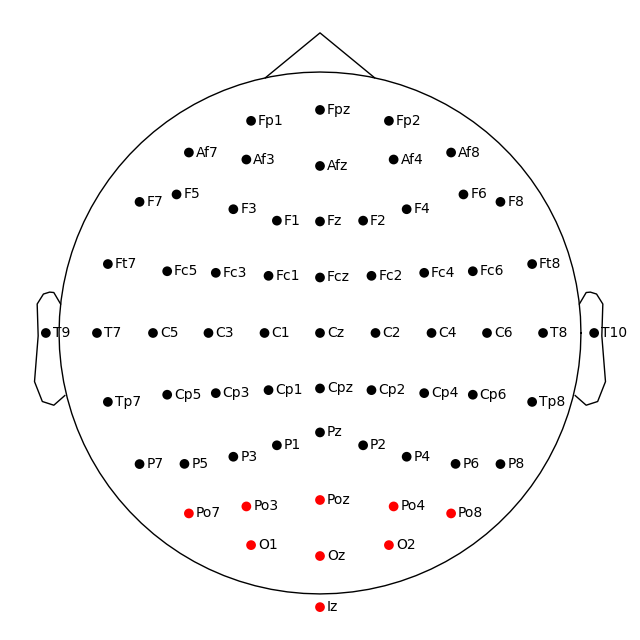

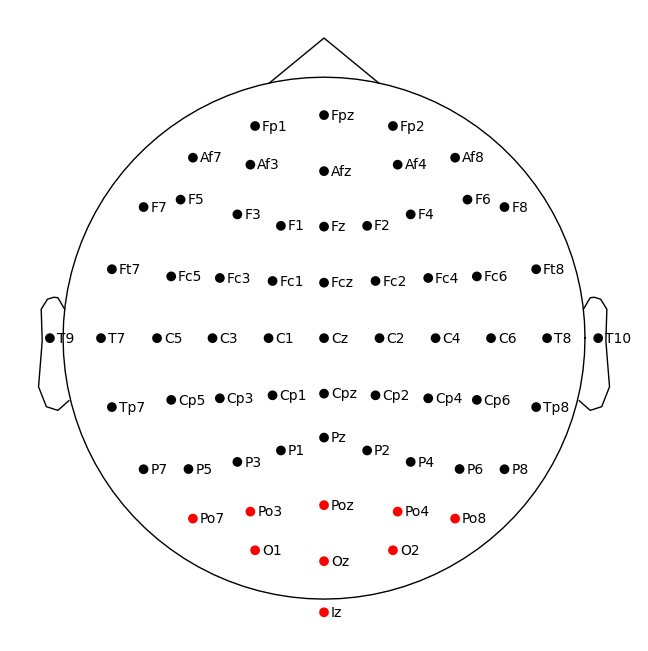

In [127]:
# processed.compute_psd().plot_topomap()
# Plot the electrode positions
processed.plot_sensors(show_names=True)
# processed.plot(duration=10, scalings={'eeg': 50e-6})

In [26]:
# # Print the annotations of the raw data
# onset=[]
# duration=[]
# description=[]
# for idx, annotation in enumerate(raw.annotations):
#     onset.append(annotation["onset"])
#     if idx != len(raw.annotations) - 1:
#         duration.append(round(raw.annotations[idx + 1]["onset"] - annotation["onset"] - 0.1, 2))
#     else:
#         duration.append(round(125 - annotation["onset"] - 0.1, 2))
#     description.append(annotation["description"])

# new_annotations = mne.Annotations(onset=onset, duration=duration, description=description)
# rawCopy.set_annotations(new_annotations)

# for annotation in rawCopy.annotations:
#     print(annotation)

In [117]:
# Create epochs from the raw data
epochs = mne.Epochs(processed, tmin=-2, tmax=1.5, baseline=(-2,0), preload=True)
epochs.crop(tmin=0, tmax=1.5)
# Print the epochs to verify
print(epochs)

Used Annotations descriptions: [np.str_('TASK1T0'), np.str_('TASK1T1'), np.str_('TASK1T2')]
Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 561 original time points ...
1 bad epochs dropped
<Epochs | 29 events (all good), 0 – 1.5 s (baseline -2 – 0 s (baseline period was cropped after baseline correction)), ~3.5 MB, data loaded,
 np.str_('TASK1T0'): 14
 np.str_('TASK1T1'): 8
 np.str_('TASK1T2'): 7>


In [118]:
# Separate epochs by type
left_epochs = epochs['TASK1T1']
right_epochs = epochs['TASK1T2']

alpha_band = (8, 13)
# channels = ["Fcz", "Fc1", "Fc2", "Fc3", "Fc4", "Cz", "C1", "C2", "C3", "C4", "Cpz", "Cp1", "Cp2", "Cp3", "Cp4"]
channels = "all"

psd_left = left_epochs.compute_psd(fmin=alpha_band[0], fmax=alpha_band[1], picks=channels)
psd_right = right_epochs.compute_psd(fmin=alpha_band[0], fmax=alpha_band[1], picks=channels)

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


In [119]:
psd_left_data, freqs_left = psd_left.get_data(return_freqs=True)
psd_right_data, freqs_right = psd_right.get_data(return_freqs=True)

psd_left_mean = psd_left_data.mean(axis=-1) # Shape: (n_epochs, n_channels)
psd_right_mean = psd_right_data.mean(axis=-1)

psd_left_avg = psd_left_mean.mean(axis=0) # Shape: (n_channels,)
psd_right_avg = psd_right_mean.mean(axis=0)

psd_diff = psd_left_avg - psd_right_avg

In [120]:
epochs.drop_channels(epochs.info['bads'])
print(epochs.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 55 EEG
 custom_ref_applied: True
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 8.0 Hz
 lowpass: 30.0 Hz
 meas_date: unspecified
 nchan: 55
 projs: []
 sfreq: 160.0 Hz
>


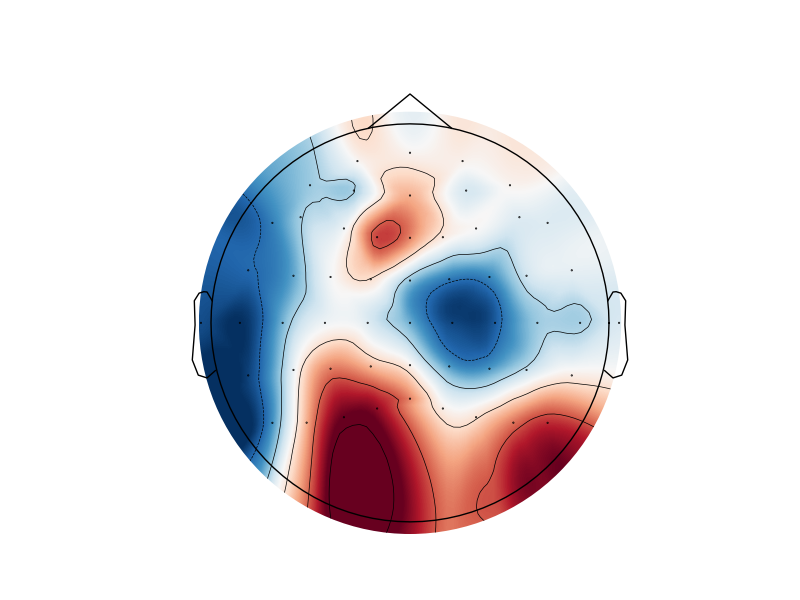

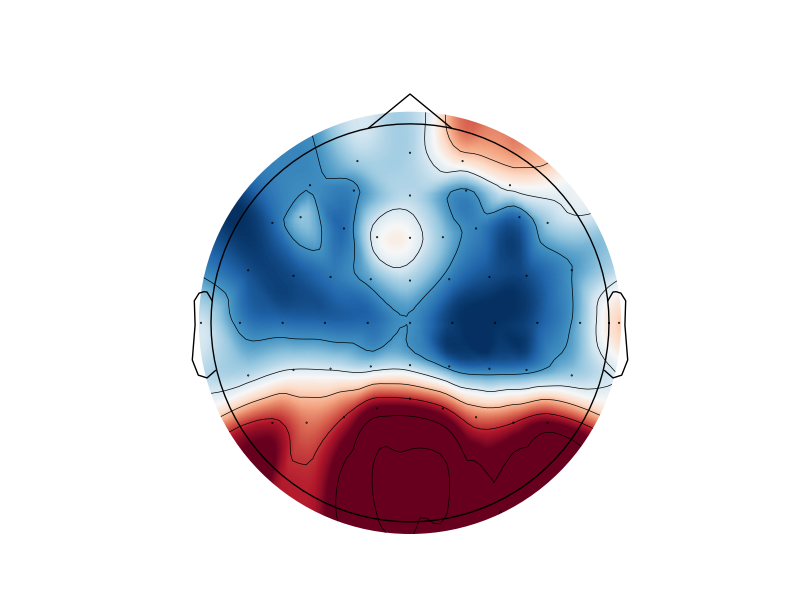

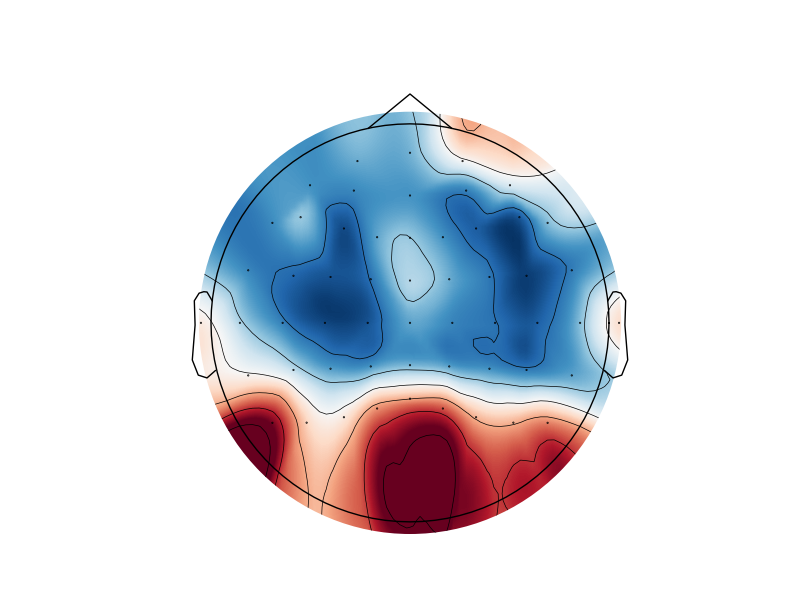

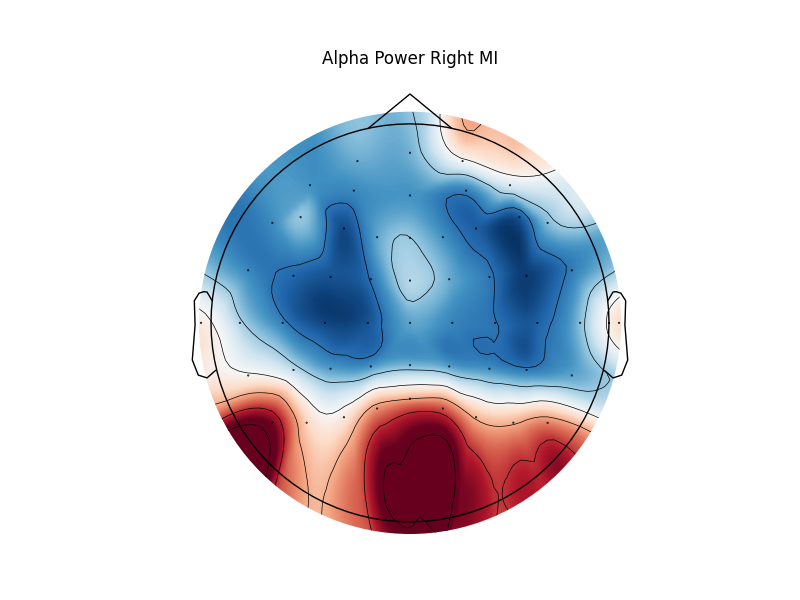

In [122]:
fig, ax = plt.subplots(figsize=(8, 6))
mne.viz.plot_topomap(psd_diff, epochs.info, axes=ax, show=True,
                     cmap='RdBu_r', vlim=(np.min(psd_diff), np.max(psd_diff)))
ax.set_title('Alpha Power Difference (Left MI - Right MI)')

fig, ax = plt.subplots(figsize=(8, 6))
mne.viz.plot_topomap(psd_left_avg, epochs.info, axes=ax, show=True,
                     cmap='RdBu_r', vlim=(min(np.min(psd_left_avg), np.min(psd_right_avg)), max(np.max(psd_left_avg), np.max(psd_right_avg))))
ax.set_title('Alpha Power Left MI')

fig, ax = plt.subplots(figsize=(8, 6))
mne.viz.plot_topomap(psd_right_avg, epochs.info, axes=ax, show=True,
                     cmap='RdBu_r', vlim=(min(np.min(psd_left_avg), np.min(psd_right_avg)), max(np.max(psd_left_avg), np.max(psd_right_avg))))
ax.set_title('Alpha Power Right MI')
plt.show()

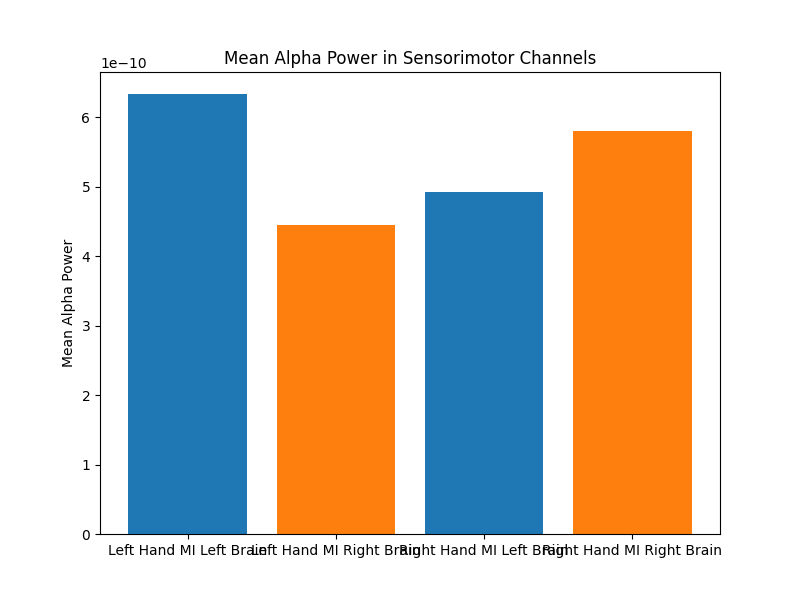

In [126]:
# Select channels of interest (e.g., C3 and C4)
# channels_of_interest = ["Fcz", "Fc1", "Fc2", "Fc3", "Fc4", "Cz", "C1", "C2", "C3", "C4", "Cpz", "Cp1", "Cp2", "Cp3", "Cp4"]
left_channels_of_interest = ["Fc1", "Fc3", "C1", "C3", "Cp1", "Cp3"]
right_channels_of_interest = ["Fc2", "Fc4", "C2", "C4", "Cp2", "Cp4"]
left_channel_indices = [epochs.ch_names.index(ch) for ch in left_channels_of_interest]
right_channel_indices = [epochs.ch_names.index(ch) for ch in right_channels_of_interest]

# Extract mean alpha power for these channels
alpha_left_hand_left = psd_left_avg[left_channel_indices].mean()
alpha_left_hand_right = psd_left_avg[right_channel_indices].mean()
alpha_right_hand_left = psd_right_avg[left_channel_indices].mean()
alpha_right_hand_right = psd_right_avg[right_channel_indices].mean()

# Plot bar chart
conditions = ['Left Hand MI Left Brain', 'Left Hand MI Right Brain', 'Right Hand MI Left Brain', 'Right Hand MI Right Brain']
alpha_values = [alpha_left_hand_left, alpha_left_hand_right, alpha_right_hand_left, alpha_right_hand_right]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(conditions, alpha_values, color=['tab:blue','tab:orange','tab:blue','tab:orange'])
ax.set_ylabel('Mean Alpha Power')
ax.set_title('Mean Alpha Power in Sensorimotor Channels')
plt.show()